In [2]:
import MDAnalysis as mda
import os, sys, glob

from openmm import *
from openmm.app import *
from openmm.unit import *

sys.path.append('/media/volume/Josephs-Volume/githubs/Bridgeport/')

import ForceFields.ForceFieldHandler as ff_handler
from Ligand.Ligand import Ligand
from ForceFields.OpenMMJoiner import Joiner

In [8]:
# Chop a protein to a hybrid solvent
bridgeport_output_pdb = '/media/volume/Josephs-Volume/githubs/Bridgeport/5HT2B/systems/6drx_h8g.pdb'
bridgeport_output_xml = '/media/volume/Josephs-Volume/githubs/Bridgeport/5HT2B/systems/6drx_h8g.xml'

In [10]:
#Simulate MotorRow system analogous to gas/im/obc
#simulate_from_filepair(bridgeport_output_pdb, bridgeport_output_xml, working_dir='implicit_membrane_equil/simulations/MotorRowGas')

In [11]:
with open('implicit_membrane_equil/simulations/Mem_2A/input_sys.xml', 'r') as f:
    test_sys = XmlSerializer.deserialize(f.read())

In [14]:
for force in test_sys.getForces():
    print(force)
    print(force.getEnergyFunction())

<openmm.openmm.HarmonicBondForce; proxy of <Swig Object of type 'OpenMM::HarmonicBondForce *' at 0x77ceca7f5ff0> >


AttributeError: 'HarmonicBondForce' object has no attribute 'getEnergyFunction'

In [3]:
#Just run motor row on in bridgeport outputs to equilibrate

from MotorRow import MotorRow

MR = MotorRow(pdb_file=bridgeport_output_pdb, system_xml=bridgeport_output_xml, working_directory='implicit_membrane/MotorRowEquil/')

final_files = MR.main(bridgeport_output_pdb)

In [3]:
#Chop the motorrow output
bridgeport_output_pdb = '/media/volume/Josephs-Volume/githubs/MotorRow/implicit_membrane/MotorRowEquil/Step_5_wrapped.pdb'

In [4]:
def select_whole_residues(universe, selection_string):
    group1 = universe.select_atoms(selection_string)
    return universe.select_atoms('same residue as group group1', group1=group1)

In [5]:
def parameterize_from_pdb(pdb_file, nonbondedMethod=CutoffNonPeriodic, nonbondedCutoff=1.0*nanometer,
                          lig_resname='UNK', cleanup=True, build_w_obc2=False):

    #Seperate the stuff
    uni = mda.Universe(pdb_file)
    print(len(uni.atoms))
    not_lig = uni.select_atoms(f'not resname {lig_resname}')
    lig = uni.select_atoms('resname UNK')
    not_lig.write('dummy_P.pdb')
    lig.write('dummy_L.pdb')

    #Get the Parameters
    ff_xmls = ['amber14/protein.ff14SB.xml',
               'amber14/lipid17.xml',
               '/media/volume/Josephs-Volume/githubs/Bridgeport/ForceFields/wat_opc3.xml']

    #if build_w_obc2:
    #    ff_xmls.append('implicit/obc2.xml')
    
    ff = ForceField(*ff_xmls)
    pdb = PDBFile('dummy_P.pdb')
    rec_top, rec_pos = pdb.getTopology(), pdb.getPositions()
    rec_sys = ff.createSystem(rec_top, nonbondedMethod=nonbondedMethod, nonbondedCutoff=nonbondedCutoff)
    
    #Ligand Too
    ligand = Ligand(working_dir='./', name='dummy_L', resname='UNK', smiles="CCN(CC)C(=O)N[C@@H]1CN([C@@H]2Cc3c[nH]c4c3c(ccc4)C2=C1)C")
    ligand.prepare_ligand()
    lig_sys, lig_top, lig_pos = ff_handler.ForceFieldHandler('dummy_L.sdf').main(use_pme='NoCutoff')
    
    #Joiner
    sys, top, pos = Joiner((lig_sys, lig_top, lig_pos), (rec_sys, rec_top, rec_pos)).main()
    print(sys.getNumParticles())
    for force in sys.getForces():
        if hasattr(force, 'getNonbondedMethod'):
            print(force)
            print(force.getNonbondedMethod(), force.getNumParticles())
    
    
    
    if cleanup:
        os.remove('dummy_P.pdb')
        os.remove('dummy_L.pdb')
        os.remove('dummy_L.sdf')
    
    return sys, top, pos

In [20]:
def implicit_membrane_force(system, nonbonded_cutoff=None, nonbonded_method=0,):
    #4pi = 12.56637
    """
    Just build the force, doesn't add it to the system
    nonbonded_methods 0 = NoCutoff, 1=CutoffNonPeriodic, 2=CutoffPeriodic
    """

    im_mem = CustomGBForce()
    
    _ = im_mem.addGlobalParameter('epsWater', 78.3)
    _ = im_mem.addGlobalParameter('epsMid', 3)
    _ = im_mem.addGlobalParameter('epsCore', 1)
    _ = im_mem.addGlobalParameter("soluteDielectric", 1)
    
    _ = im_mem.addGlobalParameter('thickness1', 1.2)
    _ = im_mem.addGlobalParameter('thickness2', 1.8)
    _ = im_mem.addGlobalParameter('alpha1', 7.2)
    _ = im_mem.addGlobalParameter('alpha2', 7.2)
    
    _ = im_mem.addPerParticleParameter("q")
    _ = im_mem.addPerParticleParameter("radius")
    _ = im_mem.addPerParticleParameter("scale")
    
    # See https://docs.openmm.org/latest/userguide/theory/02_standard_forces.html#gbsaobcforce
    
    #This is allegedly something called the Hawkins-Cramer-Truhlar descreening function
    _ = im_mem.addComputedValue("Imol", "step(r+sr2-or1)*0.5*(1/L-1/U+0.25*(1/U^2-1/L^2)*(r-sr2*sr2/r)+0.5*log(L/U)/r+C);"
                                "U=r+sr2;" 
                                "C=2*(1/or1-1/L)*step(sr2-r-or1);" 
                                "L=max(or1, D);" 
                                "D=abs(r-sr2);" 
                                "sr2 = scale2*or2;"
                                "or1=radius1-0.009;"
                                "or2=radius2-0.009", CustomGBForce.ParticlePairNoExclusions)

     #Define the solvent dielectric as a function of z
    _ = im_mem.addComputedValue('epsOut', 'epsCore + (epsMid - epsCore)*sigmoid1 + (epsWater-epsMid)*sigmoid2;'
                                'sigmoid1=1/(1+exp(-1*alpha1*(abs(z)-thickness1)));'
                                'sigmoid2=1/(1+exp(-1*alpha2*(abs(z)-thickness2)))', CustomGBForce.SingleParticle)
    
    #Born Radius
    _ = im_mem.addComputedValue("B", "1/(1/or - tanh(psi + 0.8*psi^2 + 4.85*psi^3)/radius);"
                              "psi=Imol*or/12.56637; or=radius-0.009", CustomGBForce.SingleParticle)
    
    #Add paired polar solvation term term (138.935456 converts e^2/nm to kJ/mol
    _ = im_mem.addEnergyTerm("-0.5*138.935456*(1/soluteDielectric-1/epsPair)*(q1*q2/f);" #Energy Term
                             "epsPair=0.5*(epsOut1 + epsOut2);" #How to deal with different eps solvents
                             "f=sqrt(r^2+B1*B2*exp(-r^2/(4*B1*B2)))", CustomGBForce.ParticlePairNoExclusions) #fGB

    #Add self polar solvation term i=j
    _ = im_mem.addEnergyTerm('-0.5*138.935456*(1/soluteDielectric-1/epsOut)*q^2/B', CustomGBForce.SingleParticle)
    
    #Self Solvent Burial (Esa*4*pi=28.3919551) with z-dependent probe size
    _ = im_mem.addEnergyTerm("28.3919551*(radius+probe)^2*(radius/B)^6;"
                             'probe=0.14 + 0.1*(1-tanh((abs(z) - thickness2)/(0.25)))', CustomGBForce.SingleParticle)

    # Copy charges and radii from NonbondedForce into GBSA
    nbf = [force for force in system.getForces() if type(force) == NonbondedForce][0]
    for index in range(nbf.getNumParticles()):
        charge, sigma, epsilon = nbf.getParticleParameters(index)
        radius = 0.4 * sigma  # Extremely Roughly better to get from a forcefield
        scaling_factor = 1.0            # OBC scaling (often 1.0)
        im_mem.addParticle((charge, radius, scaling_factor))
    
    im_mem.setNonbondedMethod(nonbonded_method)
    if nonbonded_cutoff:
        im_mem.setCutoffDistance(nonbonded_cutoff)

    return im_mem

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
sigmoid = lambda alpha, z, t: 1/(1+np.exp(-1*alpha*(np.abs(z) - t)))

This multi-layer dielectric profile can be approximated closely by a “two-slab model” in which the dielectric constant from 0 to 12Å takes a value of 1, the dielectric constant from 12 to 18Å takes a value of ∼3, and the dielectric constant beyond 18Å takes the value of bulk water.

https://www.cell.com/AJHG/fulltext/S0006-3495(08)70636-2

In [32]:
#This multi-layer dielectric profile can be approximated closely by a “two-slab model” in which the dielectric constant from 0 to 12Å takes a value of 1, the dielectric constant from 12 to 18Å takes a value of ∼3, and the dielectric constant beyond 18Å takes the value of bulk water.

domain = np.linspace(-3, 3, 1000)
epsCore = 1
Core_half_thick = 1.2
epsMid = 3
Mid_half_thick = 1.8
epsWater = 78.3

sig1 = sigmoid(7.2, domain, Core_half_thick)
sig2 = sigmoid(7.2, domain, Mid_half_thick)
epsOut = epsCore + (epsMid - epsCore)*sig1 + (epsWater-epsMid)*sig2

In [34]:
r_probe_z = lambda z, z_naught, t: 0.14 + 0.1*(1-np.tanh((np.abs(z)-z_naught)/(t)))

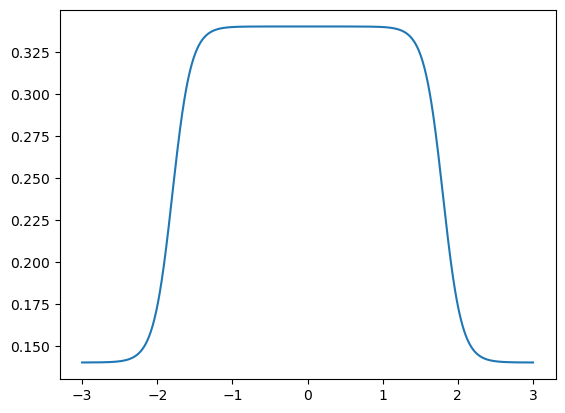

In [38]:
plt.plot(domain, r_probe_z(domain, 1.8, .25))

In [9]:
def simulate_from_filepair(pdb_top_fn, sys_xml_fn,
                           temp=300, ts=0.001, n_steps=1e6, #1ns
                           dcd_fn='output.dcd', dcd_freq=1000,
                           stdout_fn='output.stdout', stdout_freq=1000,
                           working_dir='./'):
    if not os.path.isdir(working_dir):
        os.makedirs(working_dir, exist_ok=True)
    #Construct
    pdb = PDBFile(pdb_top_fn)
    with open(sys_xml_fn, 'r') as f:
        system = XmlSerializer.deserialize(f.read())
    integrator = LangevinMiddleIntegrator(temp*kelvin, 1/picosecond, ts*picoseconds)
    sim = Simulation(pdb.topology, system, integrator)
    _ = sim.context.setPositions(pdb.positions)
    #Minimize
    _ = sim.minimizeEnergy()
    with open(os.path.join(working_dir,'minimized.pdb'), 'w') as f:
        _ = PDBFile.writeFile(sim.topology, sim.context.getState(getPositions=True).getPositions(), file=f, keepIds=True)
    #Simulate
    _ = sim.reporters.append(DCDReporter(os.path.join(working_dir, dcd_fn), dcd_freq))
    _ = sim.reporters.append(StateDataReporter(os.path.join(working_dir, stdout_fn), stdout_freq, step=True, potentialEnergy=True, temperature=True, speed=True))
    _ = sim.step(n_steps)

    #Final
    state = sim.context.getState(getPositions=True, getVelocities=True, enforcePeriodicBox=True)
    contents = XmlSerializer.serialize(state)
    with open(os.path.join(working_dir, 'final_state.xml'), 'w') as f:
        _ = f.write(contents)
    with open(os.path.join(working_dir,'final_top.pdb'), 'w') as f:
        _ = PDBFile.writeFile(sim.topology, sim.context.getState(getPositions=True).getPositions(), file=f, keepIds=True)
    return None

In [12]:
stor_dir = 'implicit_membrane_equil2_nocutoff'
if not os.path.isdir(stor_dir):
    os.makedirs(stor_dir, exist_ok=True)

name_dict = {'15A': 'protein or resname UNK or (around 15 (protein or resname UNK))',
             '10A': 'protein or resname UNK or (around 10 (protein or resname UNK))',
             '5A': 'protein or resname UNK or (around 5 (protein or resname UNK))',
             '2A': 'protein or resname UNK or (around 2 (protein or resname UNK))',
             'PL': 'protein or resname UNK'}
uni = mda.Universe(bridgeport_output_pdb)
for key, value in name_dict.items():
    group = select_whole_residues(uni, value)
    group.write(os.path.join(stor_dir, f"cut_{key}.pdb"))

/home/exouser/miniconda3/envs/prep/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


In [22]:
#Simulate multiple cutoffs in multiple conditions
# All distances in gas obc2 implicit_membrane

pdb_files = sorted(glob.glob(os.path.join(stor_dir,'*.pdb')))[::-1]
for pdb_file in pdb_files:
    for phase in ['OBC', 'Mem']:
        
        sim_dir = os.path.join(stor_dir, f'simulations/{phase}_{pdb_file.split('_')[-1].split('.')[0]}/')
        if not os.path.isdir(sim_dir):
            os.makedirs(sim_dir, exist_ok=True)
            
        print(sim_dir, phase, pdb_file)

        sys, top, pos = parameterize_from_pdb(pdb_file, nonbondedMethod=NoCutoff)
        
        if phase == 'Mem':
            _ = sys.addForce(implicit_membrane_force(sys, nonbonded_cutoff=None, nonbonded_method=0))
        
        elif phase == 'OBC2':
            nbf = [force for force in sys.getForces() if type(force) == NonbondedForce][0]
            gbsa = GBSAOBCForce()
            gbsa.setSolventDielectric(78.5)
            gbsa.setSoluteDielectric(1.0)
            gbsa.setNonbondedMethod(0)
            #gbsa.setCutoffDistance(1.0)
            for index in range(nbf.getNumParticles()):
                charge, sigma, epsilon = nbf.getParticleParameters(index)
                radius = 0.4 * sigma  # Extremely Roughly better to get from a forcefield
                scaling_factor = 1.0            # OBC scaling (often 1.0)
                gbsa.addParticle(charge, radius, scaling_factor)
            sys.addForce(gbsa)
        
        int = LangevinIntegrator(300 * kelvin, 1/picosecond, 0.001 * picosecond)
        sim = Simulation(top, sys, int)
        sim.context.setPositions(pos)

        # Save combined systems
        final_pdb = os.path.join(sim_dir, 'input_top.pdb')
        final_xml = os.path.join(sim_dir, 'input_sys.xml')
        with open(final_pdb, 'w') as f:
            PDBFile.writeFile(sim.topology, sim.context.getState(getPositions=True).getPositions(), f, keepIds=True)
        with open(final_xml, 'w') as f:
            f.write(XmlSerializer.serialize(sim.system))
        print('Done!')
        del sys, top, pos

implicit_membrane_equil2_nocutoff/simulations/OBC_PL/ OBC implicit_membrane_equil2_nocutoff/cut_PL.pdb
5756
12/05/2025 22:11:01//Saved prepared ligand to ./dummy_L.pdb ./dummy_L.sdf


[22:11:01] WARNING: More than one matching pattern found - picking one



5756
<openmm.openmm.NonbondedForce; proxy of <Swig Object of type 'OpenMM::NonbondedForce *' at 0x71055030cef0> >
0 5756
Done!
implicit_membrane_equil2_nocutoff/simulations/Mem_PL/ Mem implicit_membrane_equil2_nocutoff/cut_PL.pdb
5756
12/05/2025 22:11:03//Saved prepared ligand to ./dummy_L.pdb ./dummy_L.sdf


[22:11:03] WARNING: More than one matching pattern found - picking one



5756
<openmm.openmm.NonbondedForce; proxy of <Swig Object of type 'OpenMM::NonbondedForce *' at 0x7105368fb4f0> >
0 5756
Done!
implicit_membrane_equil2_nocutoff/simulations/OBC_5A/ OBC implicit_membrane_equil2_nocutoff/cut_5A.pdb
18970
12/05/2025 22:11:08//Saved prepared ligand to ./dummy_L.pdb ./dummy_L.sdf


...

42834
<openmm.openmm.NonbondedForce; proxy of <Swig Object of type 'OpenMM::NonbondedForce *' at 0x71053ea72630> >
0 42834
Done!
implicit_membrane_equil2_nocutoff/simulations/OBC_10A/ OBC implicit_membrane_equil2_nocutoff/cut_10A.pdb
29536
12/05/2025 22:11:46//Saved prepared ligand to ./dummy_L.pdb ./dummy_L.sdf


[22:11:46] WARNING: More than one matching pattern found - picking one



29536
<openmm.openmm.NonbondedForce; proxy of <Swig Object of type 'OpenMM::NonbondedForce *' at 0x7105201b8df0> >
0 29536
Done!
implicit_membrane_equil2_nocutoff/simulations/Mem_10A/ Mem implicit_membrane_equil2_nocutoff/cut_10A.pdb
29536
12/05/2025 22:11:55//Saved prepared ligand to ./dummy_L.pdb ./dummy_L.sdf


[22:11:55] WARNING: More than one matching pattern found - picking one



29536
<openmm.openmm.NonbondedForce; proxy of <Swig Object of type 'OpenMM::NonbondedForce *' at 0x71054209f030> >
0 29536
Done!


In [ ]:
#Simulate the systems
#given direc



    pdb_file = os.path.join(direc, 'input_top.pdb')
    xml_file = os.path.join(direc, 'input_sys.xml')
    assert os.path.isfile(pdb_file) and os.path.isfile(xml_file)
    print(os.path.isfile(pdb_file), os.path.isfile(xml_file), direc)

    _ = simulate_from_filepair(pdb_file, xml_file,
                               temp=300, ts=0.001, n_steps=1e6, #1ns
                               dcd_fn='output.dcd', dcd_freq=1000,
                               stdout_fn='output.stdout', stdout_freq=1000,
                               working_dir=direc)

#### Mess with the system

In [ ]:
#Add a flatbottom restraint to every solvent atom to the closest protein atom

In [ ]:
residues = []
for atom in top.atoms():
    if atom.residue.name not in residues:
        #print(atom.residue.name)
        residues.append(atom.residue.name)

protein_residues = residues[:-5]
solvent_residues = residues[-5:-1]

protein_residues, solvent_residues

In [ ]:
residues

In [ ]:
protein_atoms = [atom.index for atom in top.atoms() if atom.residue.name in protein_residues]

restrained_atoms = [atom.index for atom in top.atoms() if atom.residue.name in solvent_residues]

In [ ]:
add_flatbottom4solvent = True
if add_flatbottom4solvent:
    import jax
    jax_pos = jax.numpy.array([(elem[0], elem[1], elem[2]) for elem in pos._value])
    jax_restrain = jax.numpy.array(restrained_atoms)
    jax_protein = jax.numpy.array(protein_atoms)
    
    import jax.numpy as jnp
    get_dR = lambda v1, v2: v2 - v1
    square_distance = lambda dR: jnp.sum(dR**2, axis=-1)
    distance = lambda dR: jnp.sqrt(square_distance(dR))
    
    vec_distance = lambda v1, v2: distance(get_dR(v1, v2))

    dR = jax.vmap(vec_distance, in_axes=(0, None))(jax_pos[jax_restrain], jax_pos[jax_protein])
    closest_protein = jax_protein[dR.argmin(axis=-1)]

    r0 = 1.0 * nanometer
    energy = (
        "0.5 * k * step(r - rflat) * (r - rflat)^2; "
        "r = sqrt((x - x0)^2 + (y - y0)^2 + (z - z0)^2)"
    )
    
    fb_rest = CustomExternalForce(energy)
    fb_rest.addGlobalParameter("k", 1000.0 * kilojoule_per_mole / (nanometer**2))
    fb_rest.addGlobalParameter("rflat", r0)  # 0.1 nm = 1 Å
    fb_rest.addPerParticleParameter("x0")
    fb_rest.addPerParticleParameter("y0")
    fb_rest.addPerParticleParameter("z0")
    
    for i, j in zip(restrained_atoms, closest_protein):
        fb_rest.addParticle(i, [jax_pos[j][0]*nanometer, jax_pos[j][1]*nanometer, jax_pos[j][2]*nanometer])
    
    
    sys.addForce(fb_rest)

In [ ]:
add_gbsah2o = False
nbf = [force for force in sys.getForces() if type(force) == NonbondedForce][0]

if add_gbsah2o:
    
    gbsa = GBSAOBCForce()
    gbsa.setSolventDielectric(78.5)
    gbsa.setSoluteDielectric(1.0)
    gbsa.setNonbondedMethod(1)
    gbsa.setCutoffDistance(nonbondedCutoff)
    
    # Copy charges and radii from NonbondedForce into GBSA
    for index in range(nbf.getNumParticles()):
        charge, sigma, epsilon = nbf.getParticleParameters(index)
        radius = 0.4 * sigma  # Extremely Roughly better to get from a forcefield
        scaling_factor = 1.0            # OBC scaling (often 1.0)
        gbsa.addParticle(charge, radius, scaling_factor)
    
    sys.addForce(gbsa)

#### Implicit Membrane

$
I_{mol} = step(r +sr2-or1) * 0.5 * (\frac{1}{L} - \frac{1}{U} + 0.25*(\frac{1}{U^2}-\frac{1}{L^2}) * (r-\frac{sr2^2}{r}) + \frac{0.5}{r}*log(\frac{L}{U}) +C)
$

$
U=r+sr2
$

$
C=2*(\frac{1}{or1}-\frac{1}{L})*step(sr2-r-or1)
$

$
L = max(or1, D)
$

$
D=abs(r-sr2)
$

$
sr2=scale2*or2
$

$
Imem = \frac{(\frac{1}{radius}+\frac{2*log(2)}{thickness})}{(1+e^(7.2*(abs(z)+radius-0.5*thickness)))}
$

$
B = \frac{1}{\frac{1}{or} - \frac{tanh(1*\psi-0.8*\psi^2+4.85*\psi^3)}{radius}}
$

$
\psi=max(Imol,Imem)*or
$

$
or=radius-0.009
$

$
E_{term} = 28.3919551*(radius+0.14)^2*(\frac{radius}{B})^6-0.5*138.935456*(1/soluteDielectric-1/solventDielectric)*\frac{q^2}{B}
$




In [ ]:
sys.addForce(im_mem)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
e_core, e_mid, e_water = 2, 25, 78
z = np.linspace(-6,6,1000)
alpha = 2
z0 = 3
sig = lambda alpha, z, thickness: 1/(1+np.exp(-1*alpha*(np.abs(z)-thickness)))
ep_out = lambda z, alpha1, alpha2, thick1, thick2: e_core + (e_mid - e_core)*sig(alpha1, z, thick1) + (e_water-e_mid)*sig(alpha2, z, thick2)
plt.plot(z, ep_out(z, 1, 7.2, 1.5, 2.5))
plt.vlines(np.array([-4, -3, -2, 0, 2, 3, 4]), ymin=0, ymax=80, color='r', linestyle='dashed')

In [ ]:
sys.getForces()

In [ ]:
for force in sys.getForces():
    if hasattr(force, 'getNonbondedMethod'):
        print(force)
        print(force.getNonbondedMethod())

In [ ]:
# Get energy
int = LangevinIntegrator(300 * kelvin, 1/picosecond, 0.001 * picosecond)
sim = Simulation(top, sys, int)
sim.context.setPositions(pos)

In [ ]:


# Save combined systems
final_pdb = 'dummy_PL.pdb'
final_xml = 'dummy_PL.xml'
with open(final_pdb, 'w') as f:
    PDBFile.writeFile(sim.topology, sim.context.getState(getPositions=True).getPositions(), f, keepIds=True)
with open(final_xml, 'w') as f:
    f.write(XmlSerializer.serialize(sim.system))

### Analyze Simulations

In [1]:
import mdtraj as md
import os, sys, glob

stor_dir = 'implicit_membrane_equil/simulations'
sim_dirs = sorted([elem for elem in glob.glob(os.path.join(stor_dir, '*')) if os.path.isdir(elem) and os.path.basename(elem)[:3] in ['OBC', 'Mem', 'Gas']])

In [2]:
trajs = {os.path.basename(sim_dir): md.load(os.path.join(sim_dir, 'output.dcd'), top=os.path.join(sim_dir, 'input_top.pdb')) for sim_dir in sim_dirs}

In [3]:
protein_rmsds = {}
ligand_rmsds = {}

for key, traj in trajs.items():
    protein_indices = traj.top.select('protein')
    ligand_indices = traj.top.select('resname UNK')
    traj.center_coordinates()
    traj.superpose(traj, atom_indices=protein_indices)
    protein_rmsds[key] = md.rmsd(traj, traj, atom_indices=protein_indices, precentered=True)
    ligand_rmsds[key] = md.rmsd(traj, traj, atom_indices=ligand_indices, precentered=True)

/tmp/ipykernel_1879387/1911237121.py:9: RuntimeWarning: in rmsd(), precentered is ignored when atom_indices != None
  protein_rmsds[key] = md.rmsd(traj, traj, atom_indices=protein_indices, precentered=True)
/tmp/ipykernel_1879387/1911237121.py:10: RuntimeWarning: in rmsd(), precentered is ignored when atom_indices != None
  ligand_rmsds[key] = md.rmsd(traj, traj, atom_indices=ligand_indices, precentered=True)


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def plot_group(group, title):
    plt.clf()
    for key, val in group.items():
        _ = plt.plot(100*np.arange(val.shape[0])/val.shape[0], val, label=key)
    plt.xlabel('Simulation Completion (%)')
    plt.ylabel('RMSD (nm)')
    plt.legend()
    plt.title(title)
    plt.show()

In [6]:
ref_traj = md.load('/media/volume/Josephs-Volume/githubs/MotorRow/implicit_membrane/MotorRowEquil/step5.dcd', top='/media/volume/Josephs-Volume/githubs/MotorRow/implicit_membrane/MotorRowEquil/Step_5.pdb')

In [7]:
ref_traj.center_coordinates()
ref_traj.superpose(ref_traj, atom_indices= ref_traj.top.select('protein'))
protein_rmsds['Ref'] = md.rmsd(ref_traj, ref_traj, atom_indices= ref_traj.top.select('protein'), precentered=True)
ligand_rmsds['Ref'] = md.rmsd(ref_traj, ref_traj, atom_indices=ref_traj.top.select('resname UNK'), precentered=True)

/tmp/ipykernel_1879387/3698009129.py:3: RuntimeWarning: in rmsd(), precentered is ignored when atom_indices != None
  protein_rmsds['Ref'] = md.rmsd(ref_traj, ref_traj, atom_indices= ref_traj.top.select('protein'), precentered=True)
/tmp/ipykernel_1879387/3698009129.py:4: RuntimeWarning: in rmsd(), precentered is ignored when atom_indices != None
  ligand_rmsds['Ref'] = md.rmsd(ref_traj, ref_traj, atom_indices=ref_traj.top.select('resname UNK'), precentered=True)


In [8]:
mem_group = {key: val for key, val in protein_rmsds.items() if 'Mem' in key or key=='Ref'}
obc_group = {key: val for key, val in protein_rmsds.items() if 'OBC' in key or key=='Ref'}
gas_group = {key: val for key, val in protein_rmsds.items() if 'Gas' in key or key=='Ref'}

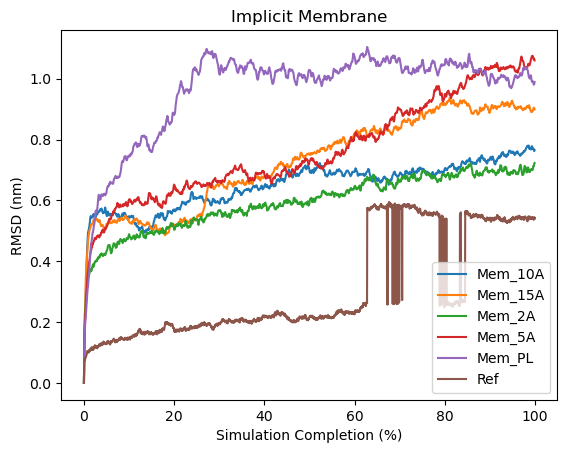

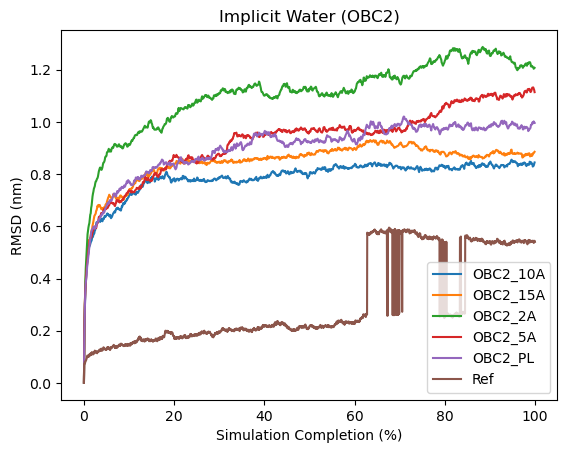

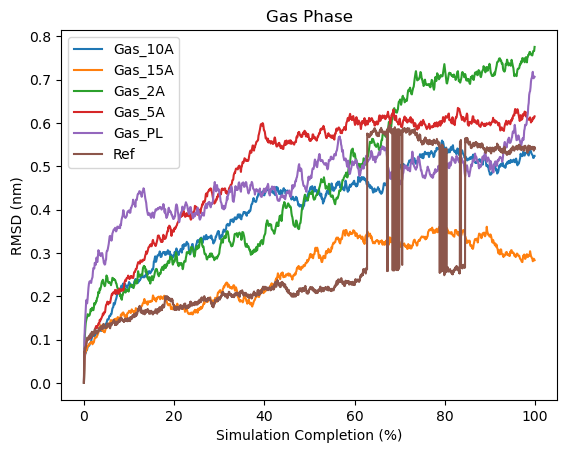

In [9]:
titles = ['Implicit Membrane', 'Implicit Water (OBC2)', 'Gas Phase']

for i, group in enumerate([mem_group, obc_group, gas_group]):
    plot_group(group, titles[i])

In [13]:
ref_traj

<mdtraj.Trajectory with 2500 frames, 75735 atoms, 18945 residues, and unitcells at 0x7e033e523b60>

In [14]:
trajs['Mem_15A']

<mdtraj.Trajectory with 1000 frames, 42834 atoms, 8237 residues, and unitcells at 0x7e03cd057b30>

#### Notes

Obtain information
- What is the benchmark for a full motorRow system in gas

Methods to change the implicit solvent
- Benchmark different nonbonded cutoffs (1.0 nm, 1.5 nm)
- Apply the dielectrics and boundaries from that publication

Methods to change the envelope
- Ellipsoidal droplets

Methods to change method
- Use grids to replace long rang electrostatics (PME)
- OpenMM GridForce to contain envelope


In [ ]:
#Becnhmark a 15A cutoff
#Try using a grid to enforce the flatbottom - talk to Jim
#Figure out how to calculate the dielectric from a simulation. - Model it for implicit membrane
# Use the publication suggestions to replace implicit membrane 
# Run an ellipsoid in gas
# Use grids to replicate long-range electrostatics (PME)
# How does all atom gas compare to all atom motorrow